<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Space X  Falcon 9 First Stage Landing Prediction**


## Hands on Lab: Complete the Machine Learning Prediction lab


Estimated time needed: **60** minutes


Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch.   In this lab, you will create a machine learning pipeline  to predict if the first stage will land given the data from the preceding labs.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planed. Space X; performs a controlled landing in the oceans.


## Objectives


Perform exploratory  Data Analysis and determine Training Labels

*   create a column for the class
*   Standardize the data
*   Split into training data and test data

\-Find best Hyperparameter for SVM, Classification Tree, Logistic Regression and K Nearest Neighbors

*   Find the method performs best using test data


## Import Libraries and Define Auxiliary Functions


In [1]:
# SB
# !pip install numpy
# !pip install pandas
# !pip install seaborn
# !pip install scikit-learn

We will import the following libraries for the lab


In [2]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

This function is to plot the confusion matrix.


In [3]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix') 
    ax.xaxis.set_ticklabels(['did not land', 'landed'])
    ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

## Load the dataframe


Load the data


In [4]:
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

In [5]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [6]:
X = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')

In [7]:
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


## TASK  1


Create a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>  then
assign it  to the variable <code>Y</code>,make sure the output is a  Pandas series (only one bracket df\['name of  column']).


In [8]:
Y = data['Class'].to_numpy()

## TASK  2


Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [9]:
# students get this 
transform = preprocessing.StandardScaler()

X = transform.fit_transform(X) # SB: scale data (fit_transform X => data leakeage =>> fit_transform X_train, transform X_test)

We split the data into training and testing data using the  function  <code>train_test_split</code>.   The training data is divided into validation data, a second set used for training  data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


## TASK  3


Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to  0.2 and random_state to 2. The training data and test data should be assigned to the following labels.


<code>X_train, X_test, Y_train, Y_test</code>


In [10]:
# Train test split with stratification since Class is imbalanced
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2, shuffle=True, stratify=Y)

we can see we only have 18 test samples.


In [11]:
Y_test.shape

(18,)

## TASK  4


Create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [12]:
# SB: redundant
# parameters ={'C':[0.01,0.1,1],
#              'penalty':['l2'],
#              'solver':['lbfgs']}

In [13]:
parameters = {"C":[0.01, 0.1, 1],'penalty':['l2'], 'solver':['lbfgs']}  # l1 lasso l2 ridge
lr = LogisticRegression()  # Logistic regression object

logreg_cv = GridSearchCV(estimator=lr, param_grid=parameters, cv=10, verbose=1)
logreg_cv.fit(X_train, Y_train)

Fitting 10 folds for each of 3 candidates, totalling 30 fits


,estimator,LogisticRegression()
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


We output the <code>GridSearchCV</code> object for logistic regression. We display the best parameters using the data attribute <code>best_params\_</code> and the accuracy on the validation data using the data attribute <code>best_score\_</code>.


In [14]:
print("tuned hyperparameters (best parameters): ",logreg_cv.best_params_)
print("accuracy: ",logreg_cv.best_score_)

tuned hyperparameters (best parameters):  {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy:  0.85


## TASK  5


Calculate the accuracy on the test data using the method <code>score</code>:


In [15]:
logreg_cv.score(X_test, Y_test)

0.8333333333333334

In [16]:
# SB: added a cell to store accuracy results for Bar Plot in a Data Report
logreg_cv_Accuracy_Train = logreg_cv.best_score_
logreg_cv_Accuracy_Test = logreg_cv.score(X_test, Y_test)

Lets look at the confusion matrix:


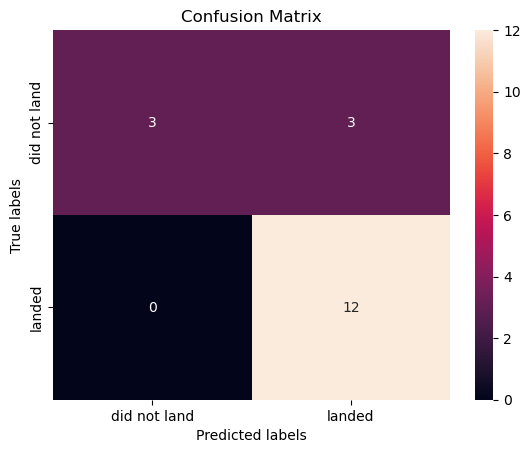

In [17]:
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

Examining the confusion matrix, we see that logistic regression can distinguish between the different classes.  We see that the problem is false positives.

Overview:

True Positive - 12 (True label is landed, Predicted label is also landed)

False Positive - 3 (True label is not landed, Predicted label is landed)


## TASK  6


Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [18]:
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()

In [19]:
svm_cv = GridSearchCV(estimator=svm, param_grid=parameters, cv=10, verbose=1)
svm_cv.fit(X_train, Y_train)

Fitting 10 folds for each of 125 candidates, totalling 1250 fits


,estimator,SVC()
,param_grid,"{'C': array([1.0000...00000000e+03]), 'gamma': array([1.0000...00000000e+03]), 'kernel': ('linear', ...)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1.0


In [20]:
print("tuned hyperparameters (best parameters):",svm_cv.best_params_)
print("accuracy:",svm_cv.best_score_)

tuned hyperparameters (best parameters): {'C': 1.0, 'gamma': 0.03162277660168379, 'kernel': 'sigmoid'}
accuracy: 0.8642857142857144


## TASK  7


Calculate the accuracy on the test data using the method <code>score</code>:


In [21]:
svm_cv.score(X_test, Y_test)

0.8333333333333334

In [22]:
# SB: added a cell to store accuracy results for Bar Plot in a Data Report
svm_cv_Accuracy_Train = svm_cv.best_score_
svm_cv_Accuracy_Test = svm_cv.score(X_test, Y_test)

We can plot the confusion matrix


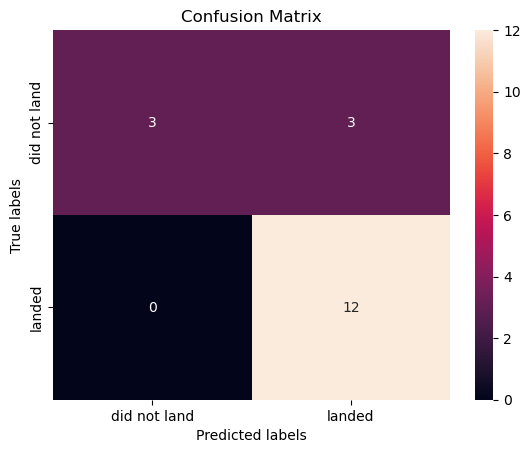

In [23]:
yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## TASK  8


Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [24]:
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
#     'max_features': ['auto', 'sqrt'],  # SB: 'auto' not officially documented, raised error
     'max_features': [None, 'sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()

In [25]:
tree_cv = GridSearchCV(estimator=tree, param_grid=parameters, cv=10, verbose=1)
tree_cv.fit(X_train, Y_train)

Fitting 10 folds for each of 648 candidates, totalling 6480 fits


,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...], 'max_features': [None, 'sqrt'], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [26]:
print("tuned hyperparameters (best parameters):",tree_cv.best_params_)
print("accuracy:",tree_cv.best_score_)

tuned hyperparameters (best parameters): {'criterion': 'gini', 'max_depth': 2, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}
accuracy: 0.9160714285714286


## TASK  9


Calculate the accuracy of tree_cv on the test data using the method <code>score</code>:


In [27]:
tree_cv.score(X_test, Y_test)

0.8333333333333334

In [28]:
# SB: added a cell to store accuracy results for Bar Plot in a Data Report
tree_cv_Accuracy_Train = tree_cv.best_score_
tree_cv_Accuracy_Test = tree_cv.score(X_test, Y_test)

We can plot the confusion matrix


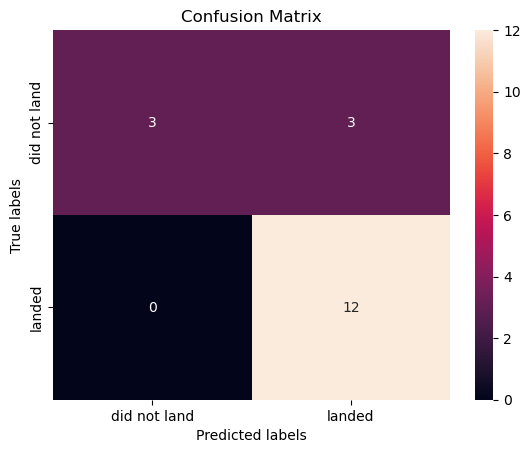

In [29]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## TASK  10


Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [30]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()

In [31]:
knn_cv = GridSearchCV(estimator=KNN, param_grid=parameters, cv=10, verbose=1)
knn_cv.fit(X_train, Y_train)

Fitting 10 folds for each of 80 candidates, totalling 800 fits


,estimator,KNeighborsClassifier()
,param_grid,"{'algorithm': ['auto', 'ball_tree', ...], 'n_neighbors': [1, 2, ...], 'p': [1, 2]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,4


In [32]:
print("tuned hyperparameters (best parameters):",knn_cv.best_params_)
print("accuracy:",knn_cv.best_score_)

tuned hyperparameters (best parameters): {'algorithm': 'auto', 'n_neighbors': 4, 'p': 1}
accuracy: 0.8642857142857142


## TASK  11


Calculate the accuracy of knn_cv on the test data using the method <code>score</code>:


In [33]:
knn_cv.score(X_test, Y_test) 

0.7777777777777778

In [34]:
# SB: added a cell to store accuracy results for Bar Plot in a Data Report
knn_cv_Accuracy_Train = knn_cv.best_score_
knn_cv_Accuracy_Test = knn_cv.score(X_test, Y_test)

We can plot the confusion matrix


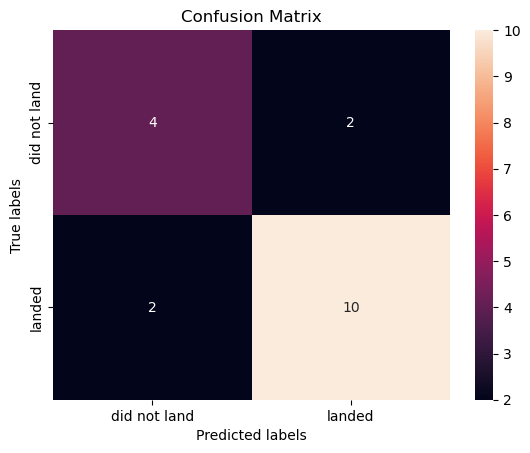

In [35]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## TASK  12


Find the method performs best:


## Summary

Logistic regression and Support Vector Machine models performs identically on test data in terms of accuracy (83.3%).  
Considering training results, Logistic Regression shows smaller gap between test and train results which  
indicates slightly better generalization than Support Vector Machine model.

| Model                 | Train Accuracy | Test Accuracy |
|:----------------------|---------------:|--------------:|
| Logistic Regression   |          85.0% |         83.3% |
| Support Vector Machine|          86.4% |         83.3% |
| Decision Tree         |          91.6% |         83.3% |
| k-Nearest Neigbors    |          86.4% |         77.8% |

## SB: Create a table with results of all the models and a bar chart for Data Report presentation 

In [36]:
# Create a dict with accuracies
results_dict = {
    'Model': ['Logistic Regression', 'Support Vector Machine', 'Decision Tree', 'k-Nearest Neigbors'],
    'Train_Accuracy': [logreg_cv_Accuracy_Train, svm_cv_Accuracy_Train, tree_cv_Accuracy_Train, knn_cv_Accuracy_Train],
    'Test_Accuracy': [logreg_cv_Accuracy_Test, svm_cv_Accuracy_Test, tree_cv_Accuracy_Test, knn_cv_Accuracy_Test]
}

# Load dict to a DataFrame and sort Test desc, Train asc
results = pd.DataFrame(results_dict).sort_values(
    by=['Test_Accuracy', 'Train_Accuracy'], 
    ascending=[False, True]
).reset_index(drop=True)

results.style.format({
    'Train_Accuracy': '{:.1%}',
    'Test_Accuracy': '{:.1%}'
})

,Model,Train_Accuracy,Test_Accuracy
0,Logistic Regression,85.0%,83.3%
1,Support Vector Machine,86.4%,83.3%
2,Decision Tree,91.6%,83.3%
3,k-Nearest Neigbors,86.4%,77.8%


In [37]:
max_Test_Accuracy = results['Test_Accuracy'].max()
max_Test_Accuracy

0.8333333333333334

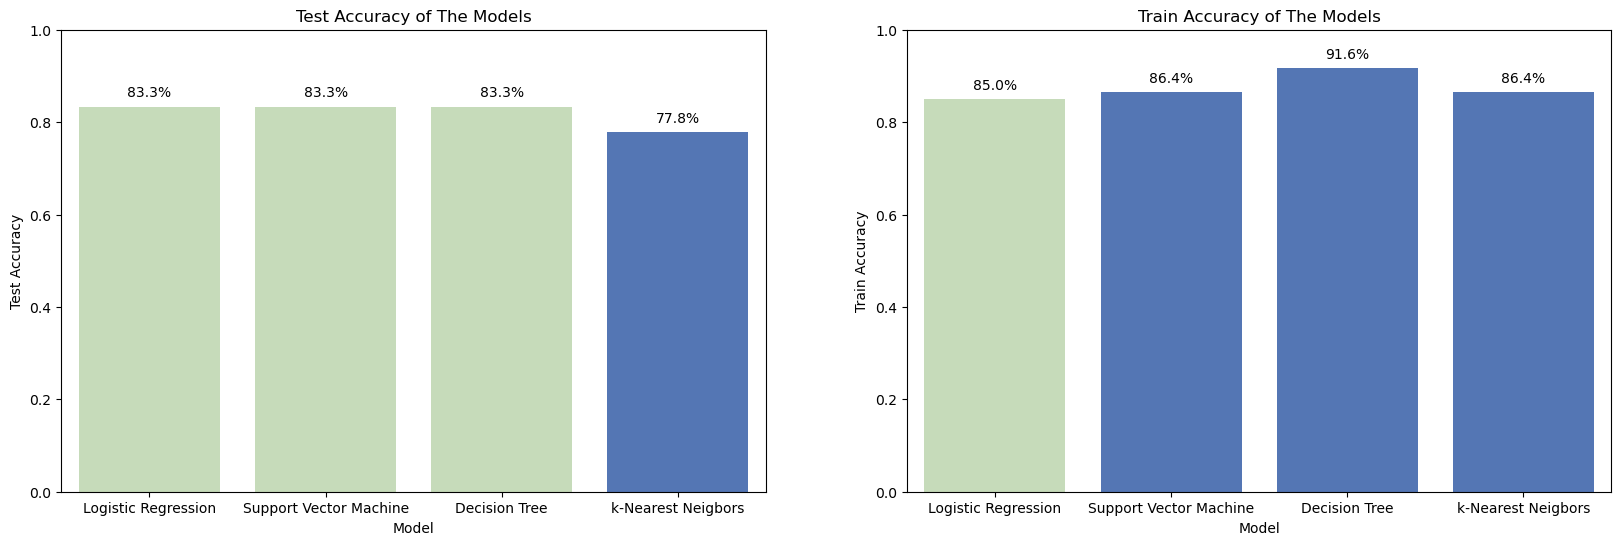

In [53]:
# Create a bar chart with train accuracy of models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

#Colors and padding
green = '#C5E0B4' 
blue = '#4472C4'
padding = 5

### Plot Test Accuracy
colors_test = [green if x==max_Test_Accuracy else blue for x in results['Test_Accuracy']]

# Bar plot
sns.barplot(x='Model', y='Test_Accuracy', data=results, hue='Model', palette=colors_test, ax=ax1)
ax1.set_ylim(0,1)
ax1.set_ylabel('Test Accuracy')
ax1.set_title('Test Accuracy of The Models')
for container in ax1.containers:
    labels=[f'{value:.1%}' for value in container.datavalues]
    ax1.bar_label(container, labels=labels, padding=padding)

### Plot Train Accuracy
colors_train = [green, blue, blue, blue]

# Bar plot
sns.barplot(x='Model', y='Train_Accuracy', data=results, hue='Model', palette=colors_train, ax=ax2)
ax2.set_ylim(0,1)
ax2.set_ylabel('Train Accuracy')
ax2.set_title('Train Accuracy of The Models')
for container in ax2.containers:
    labels=[f'{value:.1%}' for value in container.datavalues]
    ax2.bar_label(container, labels=labels, padding=padding)

plt.show()

## **Logistic Regression** is the best performing model.  
Evaluation was performed with:
* Test Set Accuracy (the highest)
* The best generalization capability => the gap between Test and Train accuracies (the lowest)

## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log--!>


<!--| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|--!>


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
